<a href="https://colab.research.google.com/github/sambee5/data-science-coursework/blob/main/Unit2/SamaBhatU2proj.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Install libraries required for analysis
!pip install preliz
import preliz as pz

import numpy as np
import pymc as pm
import arviz as az
import pandas as pd


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 519.6/519.6 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.8/108.8 kB 7.9 MB/s eta 0:00:00


Get all libraries for basic analysis. Could be changed later but this is a decent starting point

## **Introduction**
### **Motive**
* Casualties caused by traffic accidents are a leading cause of death, unnececssarily taking the lives of thousands on a daily basis
*   There is a direct link between rapidly developing infastructure and the number of traffic accidents a city encounters

### **Relevance**


*   According to the [World Health Organization](https://www.who.int/news-room/fact-sheets/detail/road-traffic-injuries
), around 1.19 million people worldwide die from road traffic crashes per year.
*   Traffic accidents are the leading cause of death among the ages ***5-29 years old***

### **Defining a Prior**


*   There is no "global crash" dataset, but we can estimate the effects of metropolitan growth on crash frequency
*   Using some element of urbanization as a prior, such as nearby construction, is a good gauge on development. It also hits close to home, as Austin is undergoing a similar infastructure boom to a lot of other bustling cities
*   I am operating under the assumption that every crash found in a construction zone was "caused" by the construction
*  I am on the road a lot of the time, whether it be going to school or coming back. I've seen a couple of crashes happen in some areas. I would estimate the car crash in construction zone probability to be around 6-7 construction zone crashes out of 100 total crashes.





<Axes: >

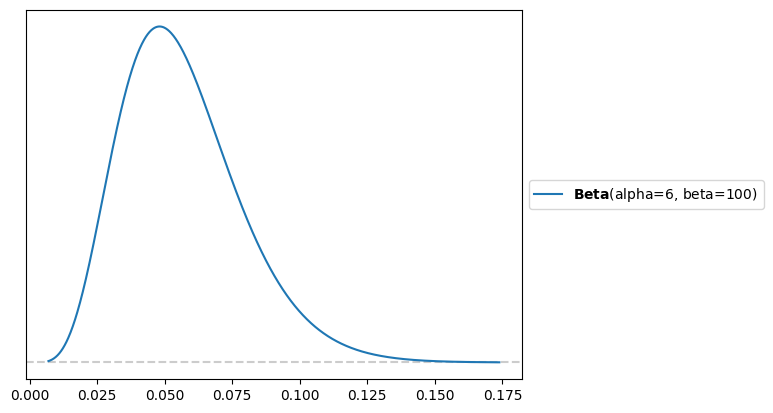

In [2]:

construction_crashes = 6
total_crashes = 100
pz.Beta(alpha=construction_crashes, beta=total_crashes).plot_pdf()

In [3]:
crash_prior = pz.Beta(alpha=construction_crashes, beta=total_crashes)

#formula to calculate the mode
crash_prior_mode = (crash_prior.alpha - 1)/(crash_prior.alpha + crash_prior.beta - 2)

#mean, median, mode of beta distribution
crash_prior.mean(), crash_prior.median(), crash_prior_mode

(np.float64(0.05660377358490566),
 0.05382955345241244,
 np.float64(0.04807692307692308))

# **Likelihood**
The prior I defined earlier isn't backed up by any statistical data or measurement. I trust that I've seen and read about enough car crashes that I can give a somewhat accurate prediction of what the prior should really be. We'll see how accurate I actually was earlier!

The dataset I'll be using is from the state and city government, and it is a very accurate dataset. It updates basically every day or so, and has definitely changed since I started and finished this project. Because this dataset is so descriptive, I'll be cutting out a lot of the data that we haven't learned to process yet, but I'm eager to revisit it once we have the tools to do so.

In [7]:

#read in the dataset from my github
construction_records = pd.read_csv("https://raw.githubusercontent.com/sambee5/data-science-coursework/refs/heads/main/Unit2/austin_crash_data.csv", low_memory=False)

#splice the dates in the timestamp column (the way it's stored is annoying)
construction_records["Crash timestamp (US/Central)"] = construction_records["Crash timestamp (US/Central)"].str[:10]

#rename the column to TIMESTAMP so code can process spaces in the old row title
construction_records.rename(columns={'Crash timestamp (US/Central)': 'TIMESTAMP'}, inplace=True)

construction_records['TIMESTAMP'] = pd.to_datetime(construction_records['TIMESTAMP'])
#get crashes between 1st day of 2023 till the day before school started this year
construction = construction_records.query(" TIMESTAMP > '2023/01/01' and  TIMESTAMP < '2025/08/19' ")


In [8]:
construction
#there are so many columns that the one I'm analyzing can't be seen. it is called road_constr_zone_fl

,ID,Crash ID,crash_fatal_fl,case_id,Primary address,Secondary address,rpt_block_num,rpt_street_name,rpt_street_sfx,crash_speed_limit,...,micromobility_serious_injury_count,micromobility_death_count,TIMESTAMP,Crash timestamp,Is deleted,Is temporary record,Law enforcement fatality count,Reported street prefix,Estimated Maximum Comprehensive Cost,Estimated Total Comprehensive Cost
1,1777668,20966790.0,False,252301657,6400 183 TOLL SB,LOYOLA LN,6400,183 TOLL SB,NaN,75.0,...,0,0,2025-08-18,08/19/2025 4:30:00 AM,False,False,0,NaN,20000,20000
2,1777664,20966782.0,False,252301493,7500 S IH 35 NB,7500 S IH 35 NB,7500,S IH 35 NB,NaN,60.0,...,0,0,2025-08-18,08/19/2025 2:33:00 AM,False,False,0,NaN,200000,220000
3,1777797,20968912.0,False,252301490,9100 N NOT REPORTED,9400 N NOT REPORTED,9100,NOT REPORTED,NaN,75.0,...,0,0,2025-08-18,08/19/2025 2:30:00 AM,False,False,0,NaN,250000,270000
4,1777704,20966788.0,False,252301355,12201 S DESSAU RD RD,1712 W SCOTTSDALE LN LN,12201,DESSAU RD,RD,40.0,...,0,0,2025-08-18,08/19/2025 12:51:00 AM,False,False,0,NaN,200000,600000
5,1778559,20980772.0,False,TX 25-1383403,NOT REPORTED,NOT REPORTED,NaN,NOT REPORTED,NaN,55.0,...,0,0,2025-08-18,08/18/2025 10:31:00 PM,False,False,0,NaN,20000,80000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32395,278343,19315212.0,False,230020126,7700 N FAR WEST TO MOPAC SB RAMP EXPY,3100 N ANDERSON RD RD,7700,FAR WEST TO MOPAC SB RAMP,EXPY,65.0,...,0,0,2023-01-02,01/02/2023 8:59:00 AM,False,False,0,NaN,20000,20000
32396,278366,19315309.0,False,230020106,500 S N IH 35 SVRD SB HWY,700 E 6TH ST,500,N IH 35 SVRD SB,HWY,35.0,...,0,0,2023-01-02,01/02/2023 8:25:00 AM,False,False,0,NaN,200000,240000
32397,278335,19315139.0,False,230020074,W RUNDBERG LN,SLAYTON DR,NaN,W RUNDBERG LN,NaN,-1.0,...,0,0,2023-01-02,01/02/2023 7:27:00 AM,False,False,0,NaN,3000000,3020000
32398,278396,19315501.0,False,230020044,900 FAIRFIELD DR DR,8600 BRIDGEPORT DR DR,900,FAIRFIELD DR,DR,30.0,...,0,0,2023-01-02,01/02/2023 7:00:00 AM,False,False,0,NaN,20000,40000


In [22]:
#get boolean values in the column (very creative variable names I know)
caused_by_construction = construction.query('road_constr_zone_fl == True').shape[0]
not_caused_by_construction = construction.query('road_constr_zone_fl == False').shape[0]

In [23]:
caused_by_construction

2845

In [24]:
not_caused_by_construction

29549

In [25]:
all_crashes = caused_by_construction + not_caused_by_construction
all_crashes

32394

I've gathered all the data we need for the likelihood. A couple thoughts before making a graph:


*   the number of crashes calculated got in all_crashes isn't equal to the number of rows
*   the 5 rows that did not get counted are likely issues with the record (i.e. they are blank on the dataset)
*   I will leave those untouched because assuming they are true or false is unfair



<Axes: >

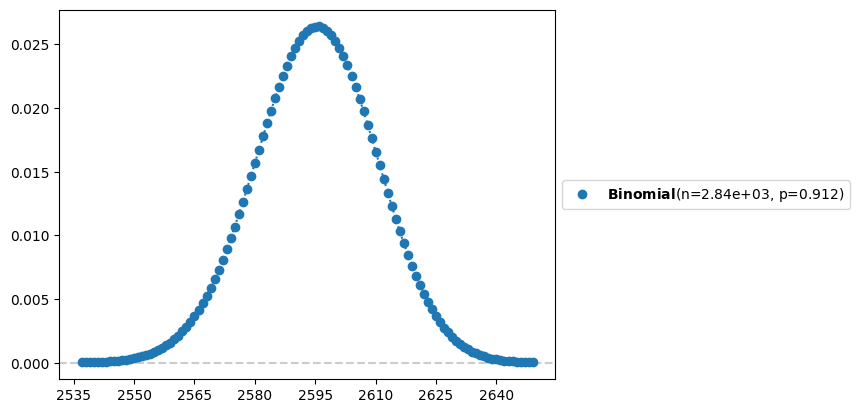

In [29]:
#the likelihood
pz.Binomial(2845, 29549/32394).plot_pdf()

# **Posterior**

In [36]:
#crashes in construction zones stored as a 1 because they are True
construction_car_crash = np.repeat(1, caused_by_construction)

#crashes not in construction zones stored as 0 because they are False
not_construction_car_crash = np.repeat(0, not_caused_by_construction)

#combine both types of crashes into one array
construction_data = np.concatenate( [construction_car_crash,not_construction_car_crash] )

with pm.Model() as constr_crash_model:
  #θ is the posterior
  θ = pm.Beta('θ' , alpha = 6. , beta = 100.)

  #that fancy looking y is the posterior
  y = pm.Bernoulli('y', p = θ, observed = construction_data)

  #samples
  posterior_constr = pm.sample(1000, progressbar=False)

<Axes: title={'center': 'θ'}>

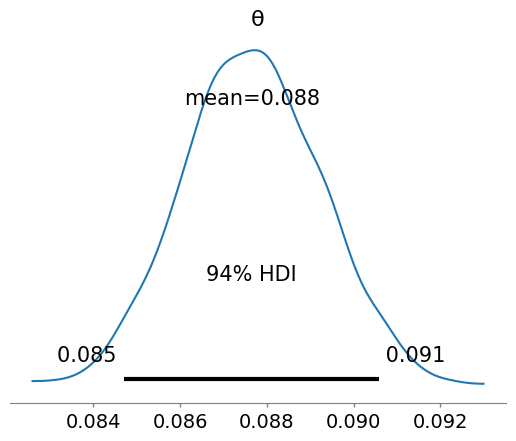

In [37]:
az.plot_posterior(posterior_constr)

# **Conclusions from PyMC Graph**
*   The probability of someone getting in a car crash in a construction zone is around 8.8%
*   This is higher than I thought because I was under the assumption that people usually avoid construction zones and would therefore get into accidents less often in those areas
* I'm still left curious about the marginal distributions of the people who get in these crashes. The research into my prior left me intrigued. What type of people are getting into these accidents?
## **What Next?**


*   This should go without saying, but try to avoid navigating roads you're unfamiliar with. Things like construction zones are a prime example of this
*   I understand that this is very difficult in a city like Austin, but this gives a pretty accurate climate of construction related accidents in other parts of the nation
* Going off vibes, I predict that cities like Denver and Pittsburgh would have similar crash percentages to that of Austin



